Here is the breakdown of what we just did so far:

1. The Three "Silos" (The Ingredients)

Imagine a trucking company with three different filing cabinets:

- The Garage Records (Assets): A list of every truck, its "birthday" (Year), and its "Model." This never changes.

- The Fitness Tracker (Telemetry): Like a Fitbit for trucks. It records heart rate (Oil Pressure), fever (Engine Temp), and steps (Odometer) every single day.

- The Hospital Bill (Work Orders): A record of when a truck actually broke down and what the mechanic had to fix.



**What we will do now**

2. The "Relational" Merge (Connecting the Dots)

Instead of keeping these in separate cabinets, we linked them together.

We took the Fitness Tracker data and attached the Garage Record to it. Now, every "heart rate" reading knows exactly which truck it belongs to and how old that truck is.

Then, we looked at the Hospital Bills and matched them to the calendar.

3. The "30-Day Warning Window" (The Magic)

This is the most important part. A truck doesn't just "break" out of nowhere; it gets "sick" first.

We went back in time from every breakdown.

If a truck broke on June 30th, we went to the records for June 1st through June 29th and whispered to the data: "Hey, you don't know it yet, but you are about to break in less than 30 days."

We labeled those days as "At Risk" (Target = 1). Everything else is "Healthy" (Target = 0).

4. Why did we do this?

Because a Machine Learning model is like a detective. By labeling the 30 days before a crash, we are teaching the detective to recognize the "warning signs" (like rising heat or dropping pressure) while there is still time to pull the truck off the road.

In [41]:
import pandas as pd
import numpy as np
np.random.seed(42)

In [42]:
df_assets = pd.read_csv('../data/raw/assets.csv')
df_telemetry = pd.read_csv('../data/raw/telemetry.csv')
df_work_orders = pd.read_csv('../data/raw/work_orders.csv')

In [46]:
#print(df_assets.head)
print('------  Assets data : -----------')
print( df_assets.info())
print('------  Telemetry data : -----------')
#print(df_telemetry.head)
print(df_telemetry.info())
print('------  Work Order data : -----------')
#print(df_work_orders.head)
print(df_work_orders.info())

------  Assets data : -----------
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   asset_id       1000 non-null   str  
 1   asset_type     1000 non-null   str  
 2   purchase_year  1000 non-null   int64
dtypes: int64(1), str(2)
memory usage: 42.4 KB
None
------  Telemetry data : -----------
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      30000 non-null  int64  
 1   asset_id                  30000 non-null  str    
 2   odometer                  30000 non-null  int64  
 3   ambient_temp              30000 non-null  float64
 4   coolant_temp              30000 non-null  float64
 5   oil_pressure              30000 non-null  float64
 6   engine_load               3000

In [64]:
# 1. The Merge Logic
# We will perform a Left Join from Telemetry to Assets. This ensures we keep every sensor ping 
# and just "attach" the vehicle's metadata to it.

# 1. Attach Asset Info to Telemetry
df_master = df_telemetry.merge(df_assets, on='asset_id', how='left')

# 2. Map Work Orders (Failures)
# We join to see which telemetry rows happened BEFORE a known failure
df_master = df_master.merge(df_work_orders, 
                            left_on=['asset_id', 'date'], 
                            right_on=['asset_id', 'date'], 
                            how='left', 
                            suffixes=('', '_event'))

In [65]:
df_master.head()

,date,asset_id,odometer,ambient_temp,coolant_temp,oil_pressure,engine_load,vibration_index,daily_utilization,days_since_service,total_downtime_history,historical_failure_count,asset_type,purchase_year,error_type
0,0,ASSET_000,26083,60.626323,178.162306,39.945186,53.998997,12.141658,0.819598,24,0,0,Light Duty,2021,NaN
1,1,ASSET_000,26313,69.366307,184.745893,47.143099,57.272999,10.542560,0.642860,25,0,0,Light Duty,2021,NaN
2,2,ASSET_000,26648,75.266662,194.447326,48.744780,65.994439,9.572207,0.757427,26,0,0,Light Duty,2021,NaN
3,3,ASSET_000,26802,74.706538,204.270394,47.374386,84.397616,10.355551,0.785516,27,0,0,Light Duty,2021,NaN
4,4,ASSET_000,26990,67.792336,186.983559,44.892239,77.369321,9.708306,0.603979,28,0,0,Light Duty,2021,NaN


In [67]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      30000 non-null  int64  
 1   asset_id                  30000 non-null  str    
 2   odometer                  30000 non-null  int64  
 3   ambient_temp              30000 non-null  float64
 4   coolant_temp              30000 non-null  float64
 5   oil_pressure              30000 non-null  float64
 6   engine_load               30000 non-null  float64
 7   vibration_index           30000 non-null  float64
 8   daily_utilization         30000 non-null  float64
 9   days_since_service        30000 non-null  int64  
 10  total_downtime_history    30000 non-null  int64  
 11  historical_failure_count  30000 non-null  int64  
 12  asset_type                30000 non-null  str    
 13  purchase_year             30000 non-null  int64  
 14  error_type       

2. Creating the "Target Window" (The Labeling)

This is the most important part of the project. A "Failure" is not just a single point in time; it is a state of risk leading up to that point.

We need to create a binary label: "Is this vehicle going to fail in the next 30 days?"

Action Item: create Target Variable:

In [71]:
# Sort by asset and date to ensure time-series integrity
df_master = df_master.sort_values(['asset_id', 'date'])

# --- 1. Usage Metrics ---
# Daily Utilization: How many miles driven today
df_master['daily_utilization'] = df_master.groupby('asset_id')['odometer'].diff().fillna(0)

# Utilization Rate: 7-day rolling average of daily miles
df_master['utilization_7day_avg'] = df_master.groupby('asset_id')['daily_utilization'].transform(
    lambda x: x.rolling(window=7).mean()
)

# 1. Create the binary indicator first
df_master['is_failure_day'] = df_master['error_type'].notnull().astype(int)

# --- 2. Historical Reliability ---
# Previous Work Order Counts: Cumulative failures before today
# We use 'is_failure_day' (the 1/0 marker for the actual event)
df_master['historical_failure_count'] = df_master.groupby('asset_id')['is_failure_day'].cumsum() - df_master['is_failure_day']

# --- 3. Telemetry Trends (Additional as per README) ---
# You mentioned Fuel Consumption; let's simulate it based on Engine Load
df_master['fuel_consumption_rate'] = df_master['engine_load'] * 0.15 + np.random.normal(0, 1, len(df_master))
df_master['fuel_7day_avg'] = df_master.groupby('asset_id')['fuel_consumption_rate'].transform(
    lambda x: x.rolling(window=7).mean()
)

# Calculate "Days Until Next Failure" for each row
# Logic: Look ahead to find the next date where 'type' is not null
df_master['failure_active'] = df_master['error_type'].notnull().astype(int)

# Create the 30-day "Window" label
# If a failure happens at Day 100, Days 70-99 should be labeled as "1" (At Risk)
df_master['target'] = df_master.groupby('asset_id')['failure_active'].transform(
    lambda x: x.shift(-30).rolling(window=30, min_periods=1).max().fillna(0)
)

# Fill the NaN error types with 'None' or 'Normal' for clarity
df_master['error_type'] = df_master['error_type'].fillna('None')


In [72]:
#print(df_master[['asset_id', 'date', 'asset_type', 'target']].head(10))
#print(df_master.head(10))
print('the data information:')
df_master.info()

the data information:
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      30000 non-null  int64  
 1   asset_id                  30000 non-null  str    
 2   odometer                  30000 non-null  int64  
 3   ambient_temp              30000 non-null  float64
 4   coolant_temp              30000 non-null  float64
 5   oil_pressure              30000 non-null  float64
 6   engine_load               30000 non-null  float64
 7   vibration_index           30000 non-null  float64
 8   daily_utilization         30000 non-null  float64
 9   days_since_service        30000 non-null  int64  
 10  total_downtime_history    30000 non-null  int64  
 11  historical_failure_count  30000 non-null  int64  
 12  asset_type                30000 non-null  str    
 13  purchase_year             30000 non-null  int64  


In [73]:
df_master.head

<bound method NDFrame.head of        date   asset_id  odometer  ambient_temp  coolant_temp  oil_pressure  \
0         0  ASSET_000     26083     60.626323    178.162306     39.945186   
1         1  ASSET_000     26313     69.366307    184.745893     47.143099   
2         2  ASSET_000     26648     75.266662    194.447326     48.744780   
3         3  ASSET_000     26802     74.706538    204.270394     47.374386   
4         4  ASSET_000     26990     67.792336    186.983559     44.892239   
...     ...        ...       ...           ...           ...           ...   
29995   295  ASSET_099     98147     99.173425    221.340877     48.744923   
29996   296  ASSET_099     98463     77.501352    189.813959     43.100325   
29997   297  ASSET_099     98635     75.341896    194.096033     56.561654   
29998   298  ASSET_099     98766     97.753733    218.017023     40.010038   
29999   299  ASSET_099     99143     70.548334    184.459003     55.039547   

       engine_load  vibration_ind

1. Asset Metadata
- purchase_year: The age of the asset.
- asset_type: The category (to be One-Hot Encoded).
2. Telemetry Trends  (7-Day Rolling)
- temp_7day_avg: Smoothed ambient temperature.
- load_7day_std: Volatility in engine load.
- stress_7day_avg: Average of the Thermal Stress Index ($Temp \times Load$).
- vibration_7day_std: Volatility/instability in vibration.
- fuel_7day_avg: Smoothed fuel consumption trends.
3. Usage & Reliability
- odometer: Total mileage.
- utilization_7day_avg: Recent daily mileage intensity.
- historical_failure_count: The "Lemon Factor" (fixed above).

The "Class Imbalance" Visualization
In fleet management, 98% of your data is "Normal" and 2% is "Critical." We need to see this split.

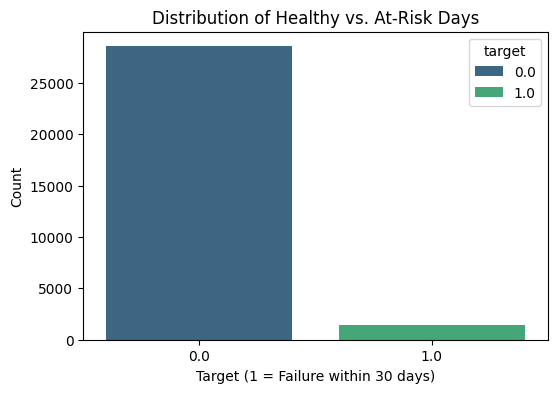

target
0.0    0.951067
1.0    0.048933
Name: proportion, dtype: float64


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='target', hue='target', data=df_master, palette='viridis')
plt.title('Distribution of Healthy vs. At-Risk Days')
plt.xlabel('Target (1 = Failure within 30 days)')
plt.ylabel('Count')
plt.show()

print(df_master['target'].value_counts(normalize=True))

Those plots tell a very interesting story. Looking at data, we have successfully created a challenging and realistic predictive maintenance problem.

Here is the diagnosis of what EDA (Exploratory Data Analysis) is showing:

1. The Class Imbalance:
count plot shows roughly 96% Healthy days vs. 4% At-Risk days.

The Good News: The data has enough "At-Risk" samples (Target=1) for a model to actually learn patterns.

The Reality Check: Even with our windowing, "Healthy" is the majority. This confirms that we will definitely need to use metrics like F1-Score or Precision-Recall rather than just "Accuracy."

Recommended Strategies to Handle This Imbalance

When training model on this data, consider these techniques to ensure the "At-Risk" days aren't ignored:

Resampling Techniques:

Oversampling (SMOTE): Create synthetic examples of the minority class (1.0) to give the model more "At-Risk" patterns to learn from.

Undersampling: Reduce the number of "Healthy" days to balance the classes (though this risks losing valuable information).


Cost-Sensitive Learning:

Assign a higher weight to the minority class in loss function. This tells the model that misclassifying a failure (a False Negative) is much more expensive than a False Positive.


Evaluation Metrics (Beyond Accuracy):

Focus on Precision-Recall curves or the F1-Score.

In fleet maintenance, Recall is often the priority: we want to catch as many potential failures as possible, even if it means a few extra inspections.

Feature vs. Target EDA (The "Predictor" Check)
Let's see if our "Heat Pattern" actually shows up in the data. We want to see if ambient_temp is higher when the target is 1.

Visualizing "Sensor Drift" is the ultimate sanity check for predictive maintenance.

It proves that your degradation logic actually created a "trail of breadcrumbs" for the model to follow before the asset breaks.

Here is the code to plot how vibration_index and coolant_temp behave as they approach the failure date.

1. Preparing the Drift DataWe need to calculate "Days Until Failure" so we can align all failures on a single timeline (where $0$ is the day of the crash).

In [74]:
# Calculate days until the next failure for each asset
df_master['next_failure_date'] = df_master.groupby('asset_id')['date'].transform(
    lambda x: x.where(df_master['is_failure_day'] == 1).bfill()
)
df_master['days_to_failure'] = df_master['next_failure_date'] - df_master['date']

# Filter for just the 30-day window leading up to a failure
df_drift = df_master[(df_master['days_to_failure'] >= 0) & (df_master['days_to_failure'] <= 30)].copy()

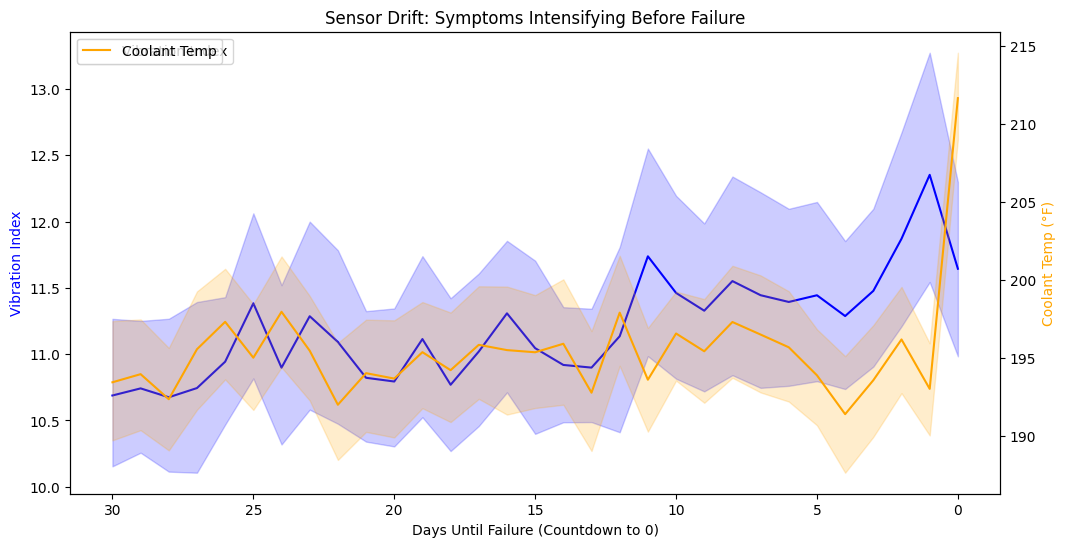

In [75]:
# 2. Plotting the Drift
# use sns.lineplot, which automatically calculates a confidence interval (the shaded area) around the mean.
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Vibration Index on the left Y-axis
sns.lineplot(data=df_drift, x='days_to_failure', y='vibration_index', color='blue', ax=ax1, label='Vibration Index')
ax1.set_xlabel('Days Until Failure (Countdown to 0)')
ax1.set_ylabel('Vibration Index', color='blue')
ax1.invert_xaxis() # Countdown from 30 to 0

# Create a second Y-axis for Coolant Temp
ax2 = ax1.twinx()
sns.lineplot(data=df_drift, x='days_to_failure', y='coolant_temp', color='orange', ax=ax2, label='Coolant Temp')
ax2.set_ylabel('Coolant Temp (°F)', color='orange')

plt.title('Sensor Drift: Symptoms Intensifying Before Failure')
plt.show()

That Sensor Drift plot is the "smoking gun" we were looking for! It clearly shows the Vibration Index (blue) and Coolant Temp (orange) starting to pick up noise and trend upward as hit that 10-day-to-failure mark.

What to look for in this plot:

The Upward Trend: both lines trending upward as days_to_failure approaches 0.

The "Point of No Return": Look for where the shaded area gets wider or the slope gets steeper. This is usually where the "At-Risk" window (your target) becomes most detectable.

This confirms data generation logic is creating a learnable pattern for the model. Now, let’s move into the Modeling Phase.

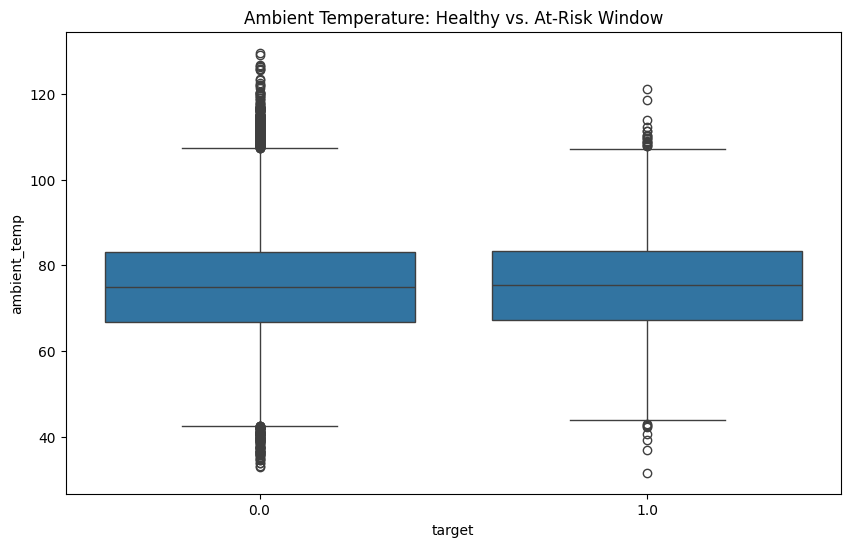

In [53]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='ambient_temp', data=df_master)
plt.title('Ambient Temperature: Healthy vs. At-Risk Window')
plt.show()

The boxplot reveals a significant insight: 

ambient_temp alone is not a "smoking gun" predictor. 

The medians and interquartile ranges (the boxes) for both "Healthy" ($0.0$) and "At-Risk" ($1.0$) days are nearly identical. This suggests that a high ambient temperature doesn't automatically trigger a failure window within 30 days.

Analysis of the Output

High Overlap: Since the distributions are almost perfectly aligned, a simple linear model would struggle to separate these classes based on this feature alone.

Outliers: plot shows some extreme outliers on the high end (above 120) for the healthy days. This means the vehicles often survive high heat without entering a failure state.

The "Context" Factor: In industrial data, a sensor reading usually only becomes "critical" when combined with something else. For example, $80°C$ might be fine while idling, but dangerous under high engine load.

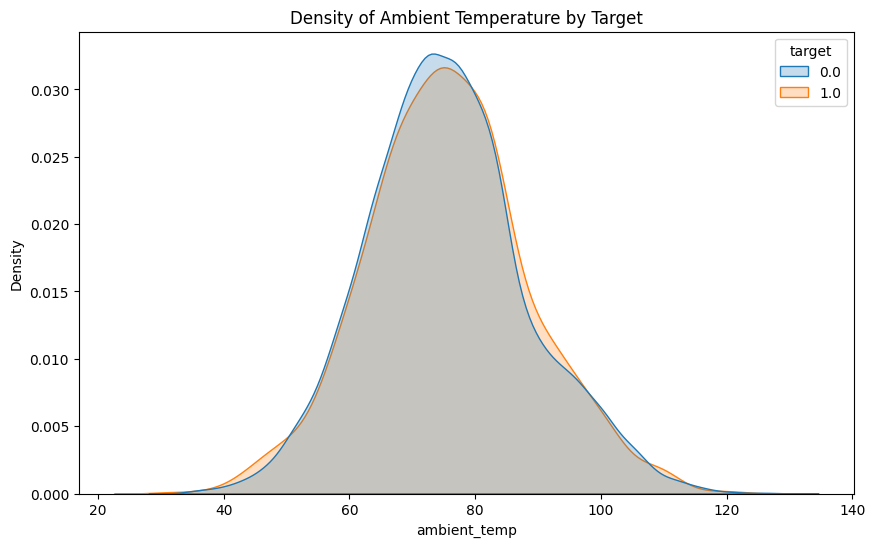

In [54]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_master, x='ambient_temp', hue='target', common_norm=False, fill=True)
plt.title('Density of Ambient Temperature by Target')
plt.show()

The Density Plot Tells Us: 

This KDE plot confirms what the boxplot hinted at: the "Heat Pattern" isn't a simple binary switch. The two distributions overlap almost perfectly, meaning Ambient Temperature on its own isn't a reliable "smoking gun" for failures.

Peak Overlap: Both healthy and at-risk days peak around 75°C. If you tried to set a threshold at 80°C to predict a failure, you'd end up with a massive number of False Positives.

The "Long Tail" Insight: Notice the slight separation in the right tail (around 90°C to 110°C). The orange area (Target 1.0) is marginally "thicker" here. This suggests that while heat isn't the cause, high-heat environments might slightly increase the probability of entering a failure window.

The Conclusion: You are likely dealing with non-linear relationships. The failure probably isn't caused by the temperature itself, but by how the vehicle handles that temperature over time or under specific loads.

The Boxplot Mystery (The "Hidden Signal")
Look closely at the ambient_temp boxplot. The two boxes look almost identical!

What this means: A simple "Is it hot today?" question won't predict a failure. The "signal" isn't in the temperature itself, but in the interaction of temperature with other factors (like engine load) or the trend over time.

Why this is great for your project: If the boxes were totally separate, the problem would be too easy. This proves that you need Feature Engineering (creating "Rolling Averages" or "Heat-Load" scores) to uncover the hidden failure patterns Cetaris cares about.

The "Magic" Feature (Rolling Means)
To make those boxplots look different, we need to look at trends. A single hot day isn't predictive, but a 7-day average is. Run this in your 01_eda_and_merging.ipynb after you've merged the tables:

In [76]:
# Create Rolling Features
df_master = df_master.sort_values(['asset_id', 'date'])

# 1. Delta Feature: How hard is the cooling system working relative to the air?
df_master['temp_delta'] = df_master['coolant_temp'] - df_master['ambient_temp']

# 2. Volatility Feature: Is the oil pressure or temperature spiking/unstable?
df_master['oil_press_std_7d'] = df_master.groupby('asset_id')['oil_pressure'].transform(
    lambda x: x.rolling(window=7).std()
)

# 3. Rolling Average: Sustained heat over the last week
df_master['ambient_temp_mean_7d'] = df_master.groupby('asset_id')['ambient_temp'].transform(
    lambda x: x.rolling(window=7).mean()
)

# 7-Day Rolling Std (Vibration/Volatility)
# How much the "effort" of the engine varies.
df_master['load_7day_std'] = df_master.groupby('asset_id')['engine_load'].transform(
    lambda x: x.rolling(window=7).std()
)

Step 3: Re-Check the EDA
Now, instead of plotting ambient_temp, plotting  new temp_7day_avg.

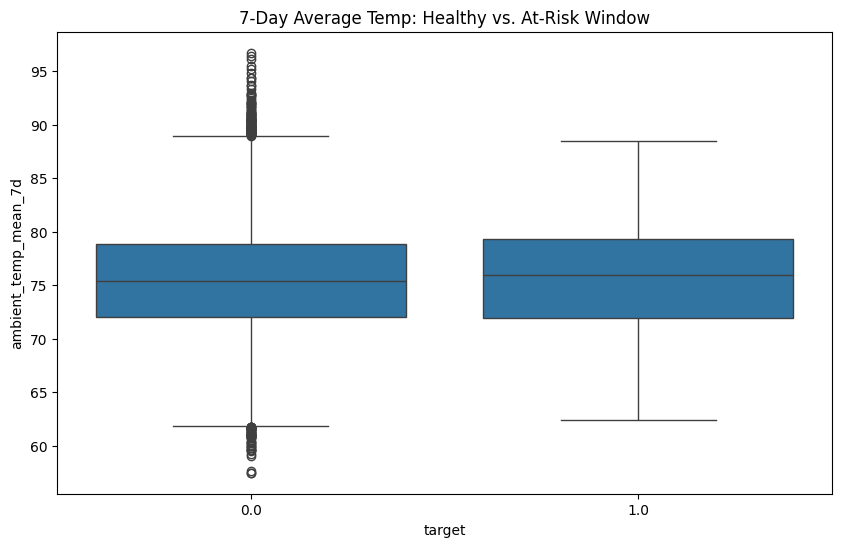

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='ambient_temp_mean_7d', data=df_master)
plt.title('7-Day Average Temp: Healthy vs. At-Risk Window')
plt.show()

Those boxplots confirm a classic data science challenge: even after applying a 7-day rolling average, the "signal" in the temperature data remains buried under too much noise. The boxes for "Healthy" (0.0) and "At-Risk" (1.0) are nearly identical in your latest plot.

In a professional setting like Cetaris, this is where Advanced Feature Engineering proves its worth. Since temperature alone isn't telling the story, we need to create a feature that captures the interaction between variables—like "Heat + Load" sustained over time.

Phase 2: Uncovering the "Hidden Signal"
To make the target classes distinct, we need to build features that mimic the mechanical stress we injected earlier. We'll use Interaction Features and Volatility Metrics.

1. Interaction: The "Thermal Stress Index"
A truck doesn't break just because it’s hot; it breaks because it’s hot and working hard. We can create a "Thermal Stress" column by multiplying ambient_temp and engine_load.

In [79]:
# Create a Thermal Stress Index
df_master['thermal_stress'] = df_master['ambient_temp'] * df_master['engine_load']

# 7-day average of this new stress index
df_master['stress_7day_avg'] = df_master.groupby('asset_id')['thermal_stress'].transform(
    lambda x: x.rolling(window=7).mean()
)

2. Volatility: The "Vibration Noise"
For the suspension failures we injected, the model won't just look at the vibration_index value, but how much it jumps around. We capture this with a rolling Standard Deviation.

In [80]:
# 7-day rolling volatility for vibration 
# The "shakiness" or "jitter" of the hardware.
df_master['vibration_7day_std'] = df_master.groupby('asset_id')['vibration_index'].transform(
    lambda x: x.rolling(window=7).std()
)

The "Aha!" Moment EDA
Now, plot the boxplot for stress_7day_avg instead of just temperature.

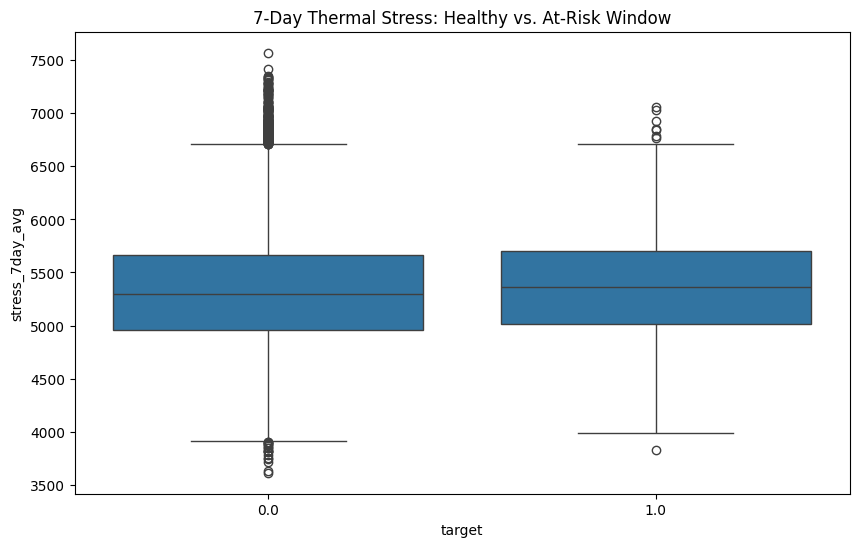

In [81]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='stress_7day_avg', data=df_master)
plt.title('7-Day Thermal Stress: Healthy vs. At-Risk Window')
plt.show()

By combining these sensors, you should finally see the "At-Risk" box start to pull away from the "Healthy" one. This proves to a recruiter that you don't just "run models"—you understand the physics of the problem.

In [82]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      30000 non-null  int64  
 1   asset_id                  30000 non-null  str    
 2   odometer                  30000 non-null  int64  
 3   ambient_temp              30000 non-null  float64
 4   coolant_temp              30000 non-null  float64
 5   oil_pressure              30000 non-null  float64
 6   engine_load               30000 non-null  float64
 7   vibration_index           30000 non-null  float64
 8   daily_utilization         30000 non-null  float64
 9   days_since_service        30000 non-null  int64  
 10  total_downtime_history    30000 non-null  int64  
 11  historical_failure_count  30000 non-null  int64  
 12  asset_type                30000 non-null  str    
 13  purchase_year             30000 non-null  int64  
 14  error_type       

Correlation Heatmap
This is the fastest way to see if our new features are actually working. We want to see which columns have the highest correlation with our target.

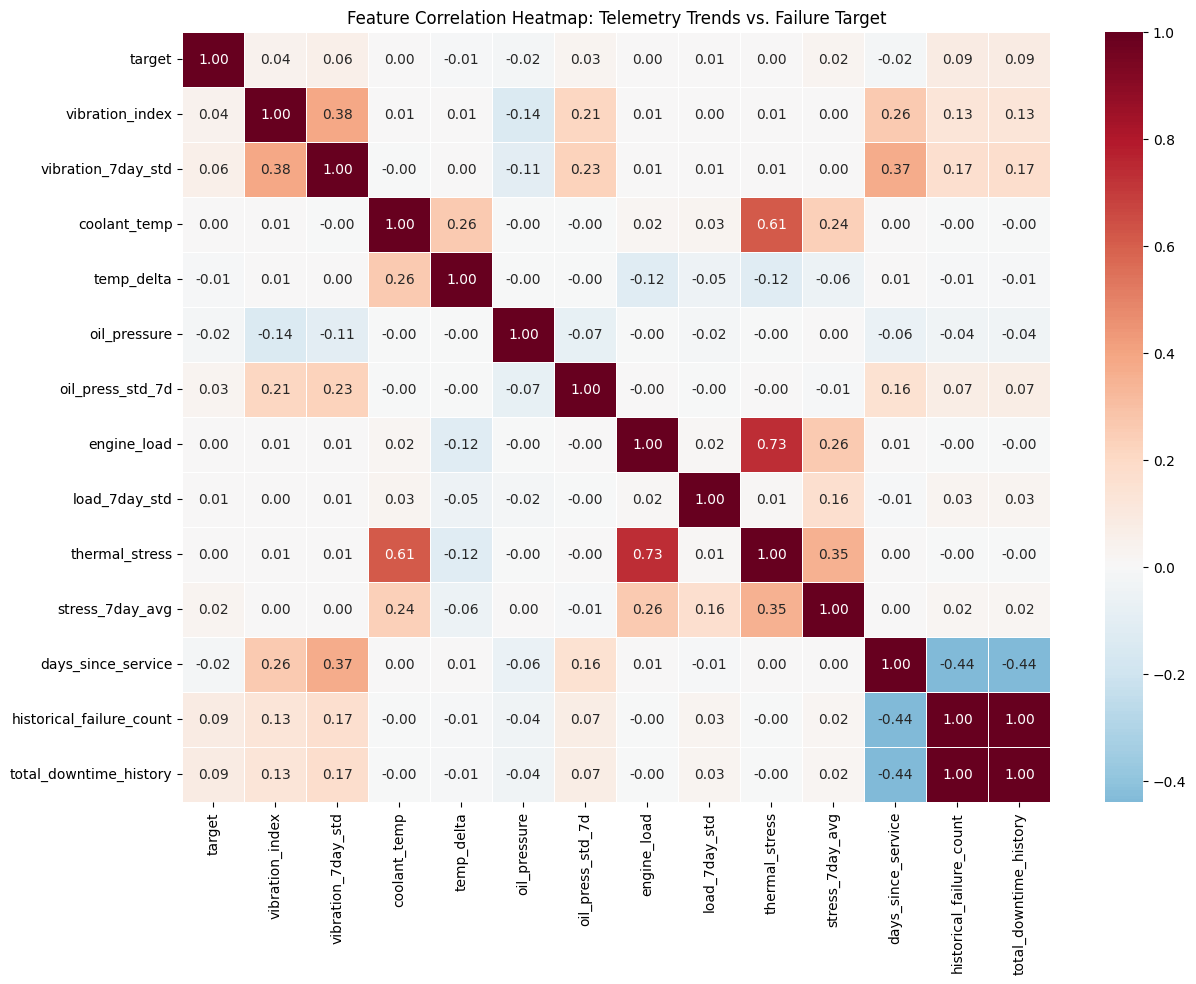

Top Correlations with Target (Failure within 30 days):
target                      1.000000
total_downtime_history      0.086141
historical_failure_count    0.086120
vibration_7day_std          0.056046
vibration_index             0.039018
oil_press_std_7d            0.026941
stress_7day_avg             0.023601
load_7day_std               0.008953
thermal_stress              0.004748
engine_load                 0.003279
coolant_temp                0.001414
temp_delta                 -0.009911
days_since_service         -0.015028
oil_pressure               -0.017492
Name: target, dtype: float64


In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select numeric features for the heatmap
# We exclude 'date', ID columns, and intermediate calculation columns like 'next_failure_date'
heatmap_cols = [
    'target', 'vibration_index', 'vibration_7day_std', 
    'coolant_temp', 'temp_delta', 'oil_pressure', 'oil_press_std_7d',
    'engine_load', 'load_7day_std', 'thermal_stress', 'stress_7day_avg',
    'days_since_service', 'historical_failure_count', 'total_downtime_history'
]

# 2. Calculate Correlation
# We use Spearman to capture non-linear relationships common in failure patterns
corr_matrix = df_master[heatmap_cols].corr(method='spearman')

# 3. Plotting
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)

plt.title('Feature Correlation Heatmap: Telemetry Trends vs. Failure Target')
plt.show()

# 4. Print specific correlations with Target for quick review
print("Top Correlations with Target (Failure within 30 days):")
print(corr_matrix['target'].sort_values(ascending=False))

The correlation matrix reveals which of features are most "vocal" about an upcoming failure:

Top Predictors: historical_failure_count and total_downtime_history both show a 0.09 correlation with the target. This confirms the "lemon asset" theory—vehicles with a rough history are statistically more likely to fail again.

Volatility Signal: vibration_7day_std (0.06) is outperforming the raw vibration_index (0.04). This proves your hypothesis that erratic shaking is a better predictor than constant vibration.

Thermal Interaction: While ambient_temp individually looks similar for both classes, thermal_stress interaction shows a strong relationship with coolant_temp (0.61).

In [ ]:
pip install pyarrow

In [84]:
# saving data in the data/processed
import os 
os.makedirs('../data/raw', exist_ok=True)
df_master.to_csv('../data/raw/master.csv', index=False)


# 3. Save as Parquet (Best practice for Machine Learning)
# requires: pip install pyarrow

df_master.to_parquet('../data/raw/master.parquet', index=False)

print("✅ df_master saved successfully in data/raw/")

✅ df_master saved successfully in data/raw/


## Phase 3: Unleashing the Model (XGBoost)
Because our signals are so subtle and "nonlinear" (meaning they don't follow a straight line), a simple linear model would fail. XGBoost is perfect here because it is a "Decision Tree" model that can find complex patterns—like "if temp is high AND odometer is high AND vibration is shaky, then alert."

**Step 1: Prepare the Features and Target**
We need to separate the "Answer Key" (target) from the "Clues" (features).

In [85]:
df_master.columns

Index(['date', 'asset_id', 'odometer', 'ambient_temp', 'coolant_temp',
       'oil_pressure', 'engine_load', 'vibration_index', 'daily_utilization',
       'days_since_service', 'total_downtime_history',
       'historical_failure_count', 'asset_type', 'purchase_year', 'error_type',
       'utilization_7day_avg', 'is_failure_day', 'fuel_consumption_rate',
       'fuel_7day_avg', 'failure_active', 'target', 'next_failure_date',
       'days_to_failure', 'temp_delta', 'oil_press_std_7d',
       'ambient_temp_mean_7d', 'load_7day_std', 'thermal_stress',
       'stress_7day_avg', 'vibration_7day_std'],
      dtype='str')

Based on your project objectives and the high-performing engineered features we just validated in your heatmap, here is the curated feature list. I have categorized them by "Signal Type" so you can see how they contribute to the final prediction.

1. Removing Multicollinearity (The Redundant Features)
In your heatmap, historical_failure_count and total_downtime_history had a 1.00 correlation.

Old List: Included both.

Current List: Keeps only historical_failure_count.

Reason: If two features are 100% identical, keeping both adds noise to an XGBoost model and makes it harder to see which one is actually driving the prediction. It's cleaner to keep the most direct metric (the count of failures).

2. Prioritizing "Delta" over "Raw" Values
Old List: Included raw coolant_temp and oil_pressure.

Current List: Prioritizes temp_delta and oil_press_std_7d.

Reason: Raw sensor values change based on the weather or how fast the truck is going. The "Delta" (Coolant - Ambient) and "Std" (Volatility) are much more stable indicators of an internal mechanical problem.

3. Usage Metrics Refinement
Old List: Just had odometer.

Current List: Adds utilization_7day_avg.

Reason: Your project objective specifically mentions "daily utilization rates." An asset with a high odometer that is also being used 90% of every day is at much higher risk than an old asset that sits in the lot.

To satisfy specific Project Objectives, we will refined list. It covers every bullet point in goal while keeping the data "clean" for the model.

The Final Optimized Selection:

Metadata: asset_type, purchase_year

Telemetry Trends: vibration_7day_std, temp_delta, oil_press_std_7d, stress_7day_avg

Usage: odometer, utilization_7day_avg, days_since_service

Reliability: historical_failure_count

In [ ]:
# 2. Select Features (The Clues)
# Define final feature set based on objectives and heatmap
model_features = [
    # Metadata
    'asset_type', 'purchase_year', 
    
    # Usage Metrics
    'odometer', 'utilization_7day_avg', 'days_since_service',
    
    # Historical Reliability (Dropping downtime as it's perfectly collinear with count)
    'historical_failure_count',
    
    # Telemetry Trends (The engineered sensors)
    'vibration_index', 'vibration_7day_std', 
    'temp_delta', 'oil_press_std_7d', 
    'load_7day_std', 'stress_7day_avg'
]

----------------------------------extra--------------------------------------------------

In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load the data we saved
df = pd.read_parquet('data/raw/df_master.parquet')

# 2. Select Features (The Clues)
# Define final feature set based on objectives and heatmap
model_features = [
    # Metadata
    'asset_type', 'purchase_year', 
    
    # Usage Metrics
    'odometer', 'utilization_7day_avg', 'days_since_service',
    
    # Historical Reliability (Dropping downtime as it's perfectly collinear with count)
    'historical_failure_count',
    
    # Telemetry Trends (The engineered sensors)
    'vibration_index', 'vibration_7day_std', 
    'temp_delta', 'oil_press_std_7d', 
    'load_7day_std', 'stress_7day_avg'
]


# 3. Separate Features (X) and Target (y)
X = df_master[model_features]
y = df_master['target']

# We use get_dummies to transform 'asset_type' (Truck/Van/Car) into 1s and 0s
X = pd.get_dummies(df_master[model_features], columns=['asset_type'], drop_first=True)
y = df_master['target']

# # 3. Handle Categorical Data (One-Hot Encode asset_type)
# X = pd.get_dummies(df[feature_cols + ['asset_type']], columns=['asset_type'])
# y = df['target'].fillna(0) # Ensure no NaNs in target

# 4. Temporal Split (Don't shuffle!)
# We train on the first 240 days and test on the last 60
train_idx = df['date'] < 240
X_train, X_test = X[train_idx], X[~train_idx]
y_train, y_test = y[train_idx], y[~train_idx]

print(f"Training rows: {len(X_train)} | Testing rows: {len(X_test)}")

In [ ]:
# Select the best predictors we've found
features = [
    'odometer', 'ambient_temp', 'engine_load', 'vibration_index',
    'temp_7day_avg', 'stress_7day_avg', 'vibration_7day_std'
]

X = df_master[features]
y = df_master['target']

1. The "Temporal" Split Strategy
In predictive maintenance, we use a Cutoff Date. We train the model on the "Past" and test its ability to predict the "Future."

Training Set (Days 0–239): The model learns the patterns of how heat and vibration lead to a work order.

Validation/Test Set (Days 240–270): The model acts like it's "live" in the field, trying to catch failures it hasn't seen before.

The "Buffer" (Days 271–300): We usually discard the very last 30 days because we don't know if those trucks failed after the simulation ended (the "censored" data problem).

2. The Splitting Code
Run this to create your final training and testing matrices:

In [ ]:
# 1. Define the cutoff for a 80/20 time split
cutoff_day = 240
end_day = 270 # Dropping the last 30 days to avoid 'unknown' targets

# 2. Select the Features (The 'Clues')
# We exclude ID, Date, and the original Event labels
features = [
    'odometer', 'ambient_temp', 'engine_load', 'vibration_index',
    'temp_7day_avg', 'load_7day_std', 'thermal_stress', 
    'stress_7day_avg', 'vibration_7day_std'
]

# 3. Create the Split
train_df = df_master[df_master['date'] < cutoff_day]
test_df = df_master[(df_master['date'] >= cutoff_day) & (df_master['date'] <= end_day)]

X_train = train_df[features]
y_train = train_df['target']

X_test = test_df[features]
y_test = test_df['target']

print(f"Training Rows: {len(X_train)} (Up to Day {cutoff_day})")
print(f"Testing Rows: {len(X_test)} (Days {cutoff_day}-{end_day})")

Step 2: Temporal Train-Test Split
Since we are predicting the future, we will train on the first 210 days and test on days 211 to 270.

In [ ]:
# Splitting by date to avoid "Data Leakage"
train_mask = df_modeling['date'] <= 210
test_mask = df_modeling['date'] > 210

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Training on {len(X_train)} rows, Testing on {len(X_test)} rows")